In [1]:
# ipca_pipeline.py (or paste into a notebook cell)

from __future__ import annotations
import os
import contextlib
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict, Any

import numpy as np
import pandas as pd
from ipca import InstrumentedPCA
%cd /Users/apple/Desktop/Academics/Research_work/TheVirtueOfComplexity_PaperReplication_Experimentation-master
import sys, importlib
import importlib
import src.ipca_workflow as IPCAWorkflow
importlib.reload(IPCAWorkflow)
import ipca
importlib.reload(ipca)
import src.grassmann_ipca_workflow as GrassmannIPCAWorkflow
importlib.reload(GrassmannIPCAWorkflow)


/Users/apple/Desktop/Academics/Research_work/TheVirtueOfComplexity_PaperReplication_Experimentation-master


<module 'src.grassmann_ipca_workflow' from '/Users/apple/Desktop/Academics/Research_work/TheVirtueOfComplexity_PaperReplication_Experimentation-master/src/grassmann_ipca_workflow.py'>

**Download Data from Openap (Run only if you need to download data)**

In [25]:
from src.data_pipeline import DataPipeline

new_mod = DataPipeline()  # or keep your existing instance if already created
char_data = new_mod.download_openap_data(start_yyyymm='199001', end_yyyymm='202512')

WRDS recommends setting up a .pgpass file.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done

Data is downloaded: 14 mins


**Data Cleaning**

In [26]:
from src.data_pipeline import DataPipeline

new_mod = DataPipeline()  # or keep your existing instance if already created

char_data, dropped_cols = new_mod.remove_mostly_nan_columns(char_data, max_nan_frac=0.5)
print(f"Dropped columns: {dropped_cols}")

Dropped columns: ['AOP', 'AbnormalAccruals', 'AccrualsBM', 'Activism1', 'Activism2', 'AdExp', 'AgeIPO', 'AnalystRevision', 'AnalystValue', 'BetaTailRisk', 'BrandInvest', 'CBOperProf', 'CPVolSpread', 'Cash', 'ChAssetTurnover', 'ChForecastAccrual', 'ChInvIA', 'ChNAnalyst', 'ChangeInRecommendation', 'CitationsRD', 'CompEquIss', 'CompositeDebtIssuance', 'ConsRecomm', 'CustomerMomentum', 'DelBreadth', 'DelDRC', 'DivSeason', 'DivYieldST', 'DownRecomm', 'EP', 'EarnSupBig', 'EarningsConsistency', 'EarningsForecastDisparity', 'EarningsStreak', 'EarningsSurprise', 'EntMult', 'ExclExp', 'FEPS', 'FR', 'FirmAgeMom', 'ForecastDispersion', 'Frontier', 'Governance', 'GrAdExp', 'GrSaleToGrInv', 'GrSaleToGrOverhead', 'HerfAsset', 'HerfBE', 'IO_ShortInterest', 'IndRetBig', 'IntanBM', 'IntanCFP', 'IntanEP', 'IntanSP', 'InvGrowth', 'Investment', 'MS', 'MeanRankRevGrowth', 'Mom6mJunk', 'MomOffSeason06YrPlus', 'MomOffSeason11YrPlus', 'MomOffSeason16YrPlus', 'MomRev', 'MomSeason06YrPlus', 'MomSeason11YrPlus',

In [27]:
char_data, kept_chars, dropped_chars = new_mod.drop_low_std_and_high_corr(
    char_data,
    min_std=1e-5,   # tune as needed
    max_corr=0.75,  # tune as needed
)
char_data = new_mod.fill_remaining_missing(char_data, use_past_only=True)
char_data_copy = char_data.copy()
char_data.head()


/usr/local/lib/python3.11/site-packages/numpy/core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/usr/local/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=

,permno,yyyymm,AM,AnnouncementReturn,AssetGrowth,BMdec,Beta,BetaFP,BetaLiquidityPS,BidAskSpread,...,ShareRepurchase,Spinoff,Tax,VolSD,VolumeTrend,betaVIX,hire,Price,Size,STreversal
0,10000,1986-01-01,1.354349,-0.005048,-0.079363,0.812997,0.939402,0.950803,-0.003676,0.010201,...,0.0,0.0,0.605906,-0.132456,-0.007507,-0.005223,-0.003373,-1.475907,-2.778819,-0.000000
1,10000,1986-02-01,1.288478,-0.006319,-0.078568,0.810572,0.943105,0.946533,-0.002954,0.009883,...,0.0,0.0,0.607135,-0.135303,-0.008091,-0.003476,-0.002513,-1.178655,-2.481568,0.257143
2,10000,1986-03-01,1.241767,-0.005388,-0.077011,0.810708,0.940686,0.945886,-0.003437,0.009717,...,0.0,0.0,0.629491,-0.139121,-0.009545,-0.002722,-0.001701,-1.490091,-2.793004,-0.365385
3,10000,1986-04-01,1.235495,-0.004667,-0.076508,0.810708,0.941277,0.885681,0.001821,0.009709,...,0.0,0.0,0.628357,-0.142124,-0.010400,0.000880,-0.000655,-1.386294,-2.719452,0.098592
4,10000,1986-05-01,1.190630,-0.001813,-0.076775,0.805317,0.940010,0.875988,-0.000560,0.009856,...,0.0,0.0,0.628310,-0.140521,-0.010711,0.008871,-0.001751,-1.134423,-2.467581,0.222656


**Characteristics of the dataset:**

In [2]:
out_path = "/Users/apple/Desktop/Academics/char_data.parquet"
char_data = pd.read_parquet(out_path, engine="pyarrow")

**Returns Data**

In [4]:
from src.data_pipeline import DataPipeline

new_mod = DataPipeline()  # or keep your existing instance if already created

returns_data = new_mod.download_sp500_returns_wrds(
    start_date="1990-01-01",
    end_date="2026-01-31",
)

WRDS recommends setting up a .pgpass file.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


**Data Cleaning**

In [5]:
returns_data = returns_data.rename(columns={"excess_ret": "ret_adj"})
char_data = new_mod.merge_openap_with_crsp_returns(char_data, returns_data)

**Main run Different K**

In [6]:
char_data.head()

,permno,yyyymm,AM,AnnouncementReturn,AssetGrowth,BMdec,Beta,BetaFP,BetaLiquidityPS,BidAskSpread,...,hire,Price,Size,STreversal,excess_ret,prc,shrout,cfacpr,cfacshr,mcap
0,10057,1990-01-01,1.999589,0.007559,0.239249,1.034177,1.051798,1.169400,-0.362514,0.009218,...,-0.039773,-2.327278,-4.166398,0.048276,-0.048276,10.25,6291.0,1.0,1.0,64482.75
1,10057,1990-02-01,2.024275,0.007559,0.239249,1.034177,1.064015,1.175841,-0.364891,0.008374,...,-0.039773,-2.315008,-4.154128,0.012195,-0.012195,10.125,6291.0,1.0,1.0,63696.375
2,10057,1990-03-01,2.249233,0.007559,-0.056259,1.102799,1.048140,1.143656,-0.380739,0.011821,...,-0.027473,-2.264364,-4.103484,0.049383,-0.049383,9.625,6291.0,1.0,1.0,60550.875
3,10057,1990-04-01,2.372478,0.000431,-0.056259,1.102799,1.044639,1.178724,-0.384304,0.007117,...,-0.027473,-2.211018,-4.050138,0.041558,-0.041558,9.125,6291.0,1.0,1.0,57405.375
4,10057,1990-05-01,2.405429,0.000431,-0.056259,1.102799,1.033924,1.203003,-0.372249,0.010140,...,-0.027473,-2.197225,-4.036345,0.013699,-0.013699,9.0,6291.0,1.0,1.0,56619.0


In [11]:
from src.grassmann_ipca_workflow import GrassmannIPCAWorkflow

wf = GrassmannIPCAWorkflow()
factors = [12,13,14,15,16]
z = 20
rff_n_components = 4096
T = 24
result = {}
for k in factors:
    all_metrics = wf.rolling_ipca_predictions(
        char_data=char_data,
        forecast_start="1993-01-01",
        target_col="y_ipca",
        n_factors=k,
        train_window_months=T,
        min_train_obs=500,
        normalize=True,
        mean_factor=True,
        silent=True,
        iter_tol=1e-4,
        warm_start=True,
        use_rff=True,
        rff_n_components=rff_n_components,
        rff_gamma=0.25,
        rff_random_state=42,
        alpha=z,
        show_progress=True,
        market_cap_filter_col="mcap",
        market_cap_filter_top_n=50,
    )
    result[k] = all_metrics

Python(3721) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Rolling IPCA:   0%|          | 0/384 [00:00<?, ?month/s]

Rolling IPCA:   0%|          | 0/384 [00:00<?, ?month/s]

Rolling IPCA:   0%|          | 0/384 [00:00<?, ?month/s]

Rolling IPCA:   0%|          | 0/384 [00:00<?, ?month/s]

Rolling IPCA:   0%|          | 0/384 [00:00<?, ?month/s]

**R2 Comparision**

In [ ]:
for k, metrics in result.items():
    pred_df_in = metrics[0]
    ss_res = ((pred_df_in["y_true"] - pred_df_in["y_pred"]) ** 2).sum()
    ss_tot = (pred_df_in["y_true"] ** 2).sum()
    r2_oos = 1 - ss_res / ss_tot
    print(f"OOS R²: {r2_oos:.4f}", f"for k={k}")

OOS R²: 0.0072 for k=12
OOS R²: 0.0079 for k=13
OOS R²: 0.0074 for k=14
OOS R²: 0.0073 for k=15
OOS R²: 0.0075 for k=16


In [19]:
import pandas as pd

all_stats = []

for k, metrics in result.items():
    pred_df_in = metrics[1]
    stats = pred_df_in.describe(include="all").T
    stats.insert(0, "k", k)
    stats = stats.reset_index().rename(columns={"index": "column"})
    stats.drop(columns=["count"], inplace=True)  # drop count if not needed
    all_stats.append(stats)

final_stats = pd.concat(all_stats, ignore_index=True)
final_stats.to_excel("prediction_stats_all.xlsx", index=False)

**Main Run Different Complexity**

In [32]:
from src.grassmann_ipca_workflow import GrassmannIPCAWorkflow

wf = GrassmannIPCAWorkflow()
k = 8
z = 20
rff_n_components = [0,128, 256, 512, 1024, 2048, 4096]
T = 24
result_rff = {}
for rff_n_component in rff_n_components:
    if rff_n_component == 0:
        use_rff = False
    else:        use_rff = True
    all_metrics = wf.rolling_ipca_predictions(
        char_data=char_data,
        forecast_start="1993-01-01",
        target_col="y_ipca",
        n_factors=k,
        train_window_months=T,
        min_train_obs=500,
        normalize=True,
        mean_factor=True,
        silent=True,
        iter_tol=1e-4,
        warm_start=True,
        use_rff=use_rff,
        rff_n_components=rff_n_component,
        rff_gamma=0.25,
        rff_random_state=42,
        alpha=z,
        show_progress=True,
        market_cap_filter_col="mcap",
        market_cap_filter_top_n=50,
    )
    result_rff[rff_n_component] = all_metrics

Rolling IPCA:   0%|          | 0/384 [00:00<?, ?month/s]

Rolling IPCA:   0%|          | 0/384 [00:00<?, ?month/s]

Rolling IPCA:   0%|          | 0/384 [00:00<?, ?month/s]

Rolling IPCA:   0%|          | 0/384 [00:00<?, ?month/s]

Rolling IPCA:   0%|          | 0/384 [00:00<?, ?month/s]

Rolling IPCA:   0%|          | 0/384 [00:00<?, ?month/s]

Rolling IPCA:   0%|          | 0/384 [00:00<?, ?month/s]

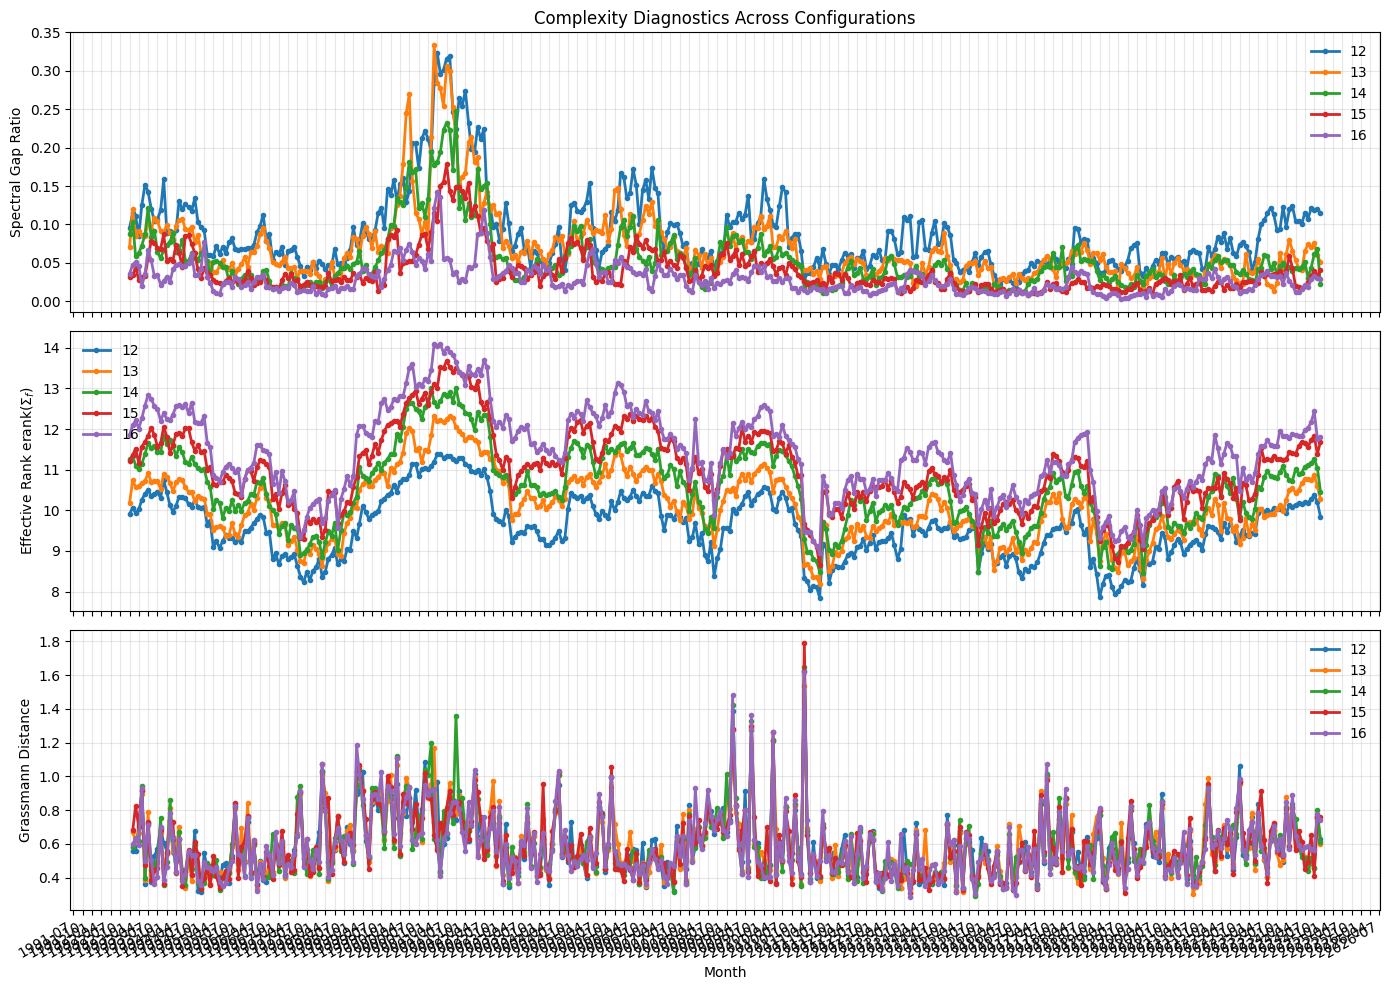

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Example:
# results = {
#     "rff=100": {"diag": diag_df_100},
#     "rff=200": {"diag": diag_df_200},
#     "rff=500": {"diag": diag_df_500},
# }

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

metric_specs = [
    ("gap_ratio", "Spectral Gap Ratio"),
    ("erank", r"Effective Rank $\mathrm{erank}(\Sigma_f)$"),
    ("grassmann_dist", "Grassmann Distance"),
]

for label, payload in result.items():
    d = payload[1]
    d["yyyymm"] = pd.to_datetime(d["yyyymm"], errors="coerce")
    
    for col, _, in metric_specs:
        if col in d.columns:
            d[col] = pd.to_numeric(d[col], errors="coerce")
    
    d = d.sort_values("yyyymm")

    for ax, (col, ylabel) in zip(axes, metric_specs):
        if col in d.columns:
            ax.plot(
                d["yyyymm"],
                d[col],
                linewidth=2,
                marker="o",
                markersize=3,
                label=str(label),
            )
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)

axes[0].set_title("Complexity Diagnostics Across Configurations")
axes[2].set_xlabel("Month")
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

for ax in axes:
    ax.legend(frameon=False)

fig.autofmt_xdate()
fig.tight_layout()
plt.show()


Annualized Return : 11.32%
Annualized Vol    : 15.05%
Sharpe Ratio      : 0.75
Max Drawdown      : -51.32%
Hit Rate          : 63.71%


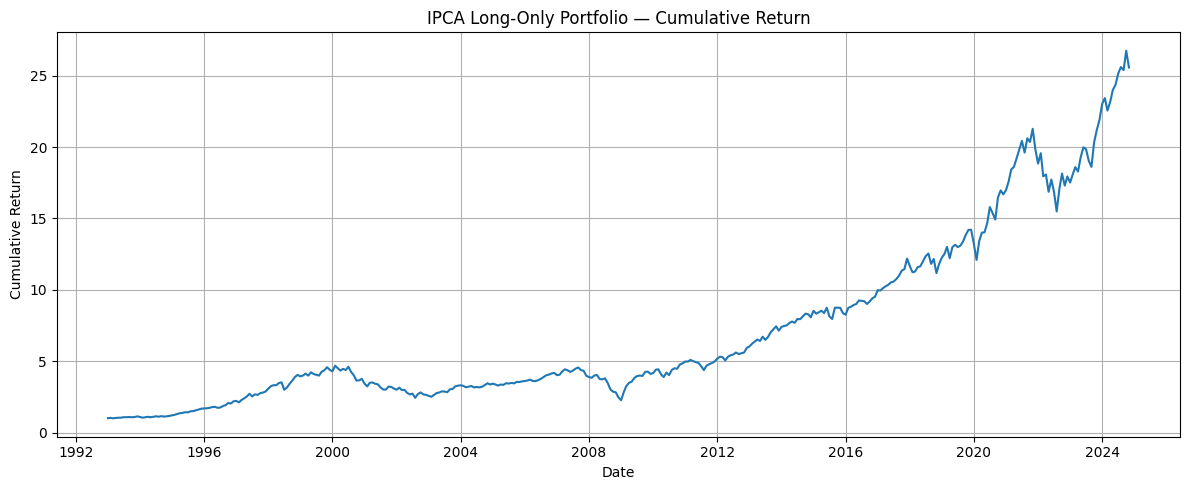

Annualized Return : 11.65%
Annualized Vol    : 15.10%
Sharpe Ratio      : 0.77
Max Drawdown      : -49.63%
Hit Rate          : 63.71%


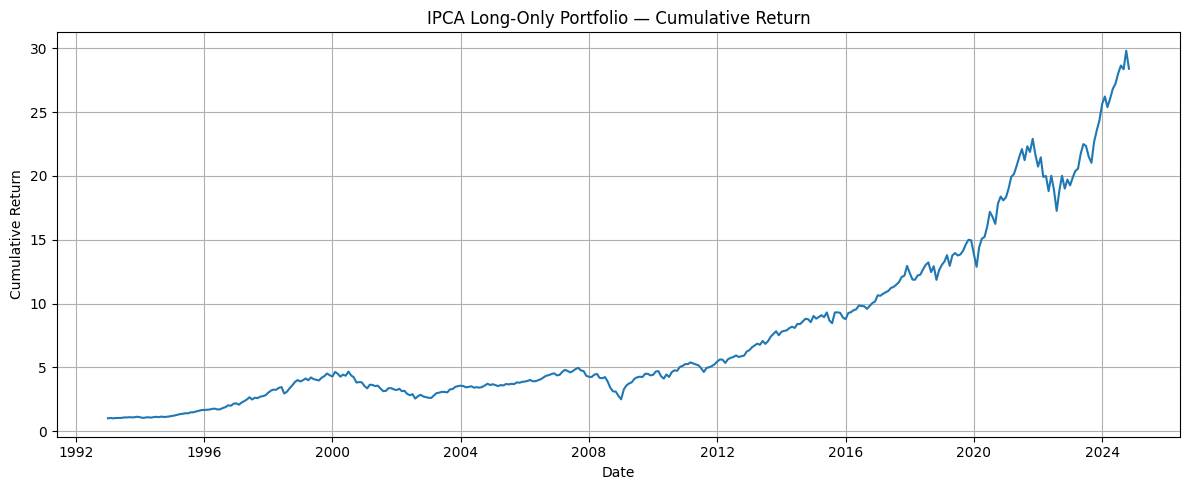

Annualized Return : 11.65%
Annualized Vol    : 14.79%
Sharpe Ratio      : 0.79
Max Drawdown      : -45.61%
Hit Rate          : 64.49%


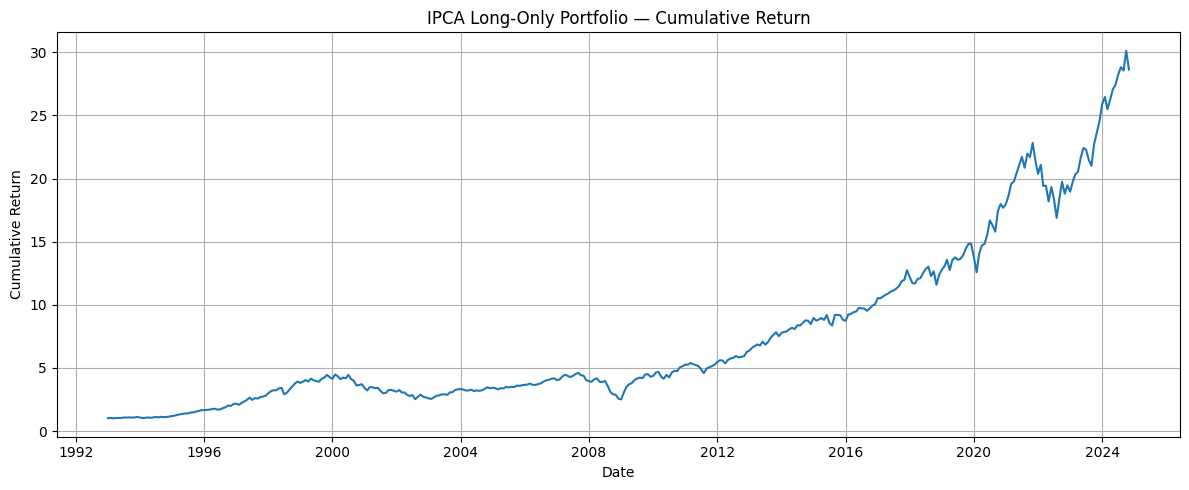

Annualized Return : 12.15%
Annualized Vol    : 16.18%
Sharpe Ratio      : 0.75
Max Drawdown      : -51.01%
Hit Rate          : 65.01%


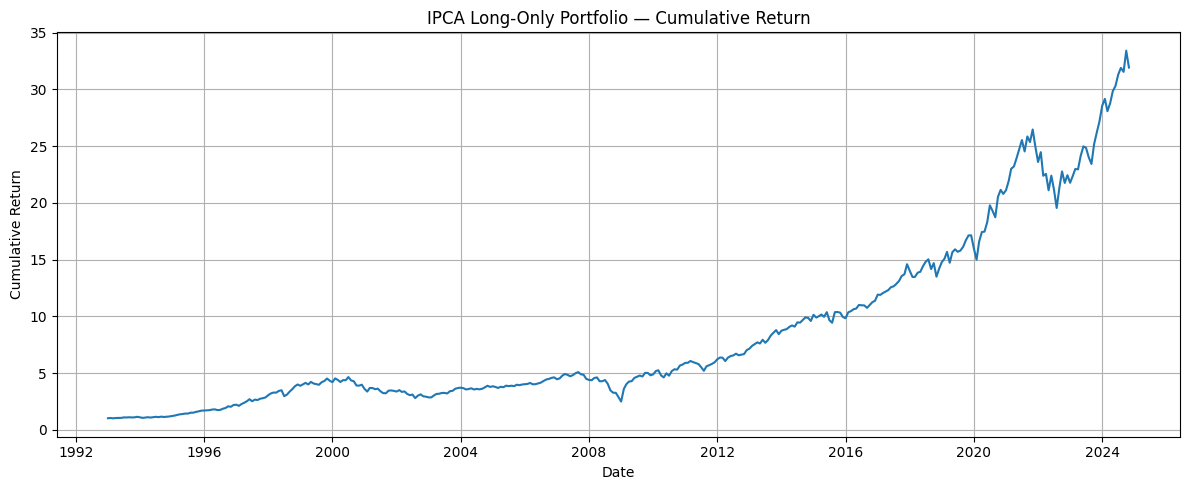

Annualized Return : 11.18%
Annualized Vol    : 14.49%
Sharpe Ratio      : 0.77
Max Drawdown      : -50.71%
Hit Rate          : 64.49%


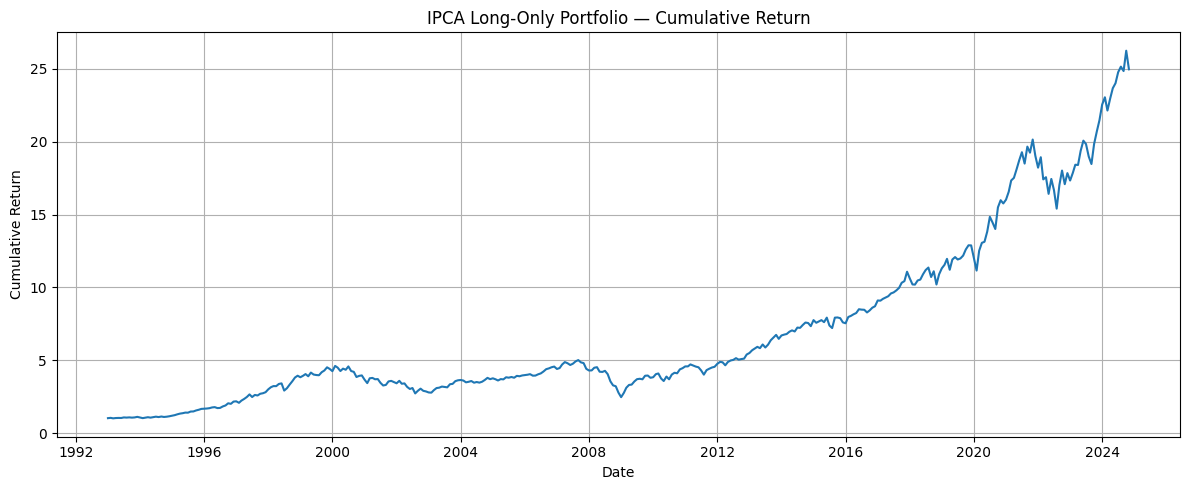

In [22]:
from src.portfolio_utils import (
    build_long_only_portfolio,
    compute_portfolio_returns,
    portfolio_performance,
    plot_cumulative,
)
portfolio_results = {}
for k, metrics in result.items():
    pred_df_in = metrics[0]  # example: k=5

    port = build_long_only_portfolio(pred_df_in, top_n=50, threshold=0.0001)
    monthly_ret = compute_portfolio_returns(port)
    stats = portfolio_performance(monthly_ret)
    plot_cumulative(monthly_ret)
    portfolio_results[k] = {
            "returns": monthly_ret,
            "performance": stats,
        }
    monthly_ret.head()


In [23]:
portfolio_performance = pd.DataFrame({
    k: res["performance"] for k, res in portfolio_results.items()
}).T.reset_index().rename(columns={"index": "k"})
portfolio_performance

,k,ann_ret,ann_vol,sharpe,max_dd,hit_rate
0,12,0.113212,0.150494,0.752272,-0.513203,0.637076
1,13,0.116513,0.150951,0.771859,-0.496329,0.637076
2,14,0.116458,0.147865,0.787595,-0.456096,0.644909
3,15,0.121511,0.161808,0.750958,-0.510127,0.650131
4,16,0.111762,0.144863,0.771504,-0.507147,0.644909


**Runs with multiple settings**

In [ ]:
from src.grassmann_ipca_workflow import GrassmannIPCAWorkflow
alphas = [10]
z = 10
wf = GrassmannIPCAWorkflow()
result_rff_all = {}
factors = [10,12,14,16,18,20]
for k in factors:
    rff_n_components = [0, 128, 256, 512, 1024, 2048, 4096]
    T = 24
    result_rff_all[k] = {}
    for rff_n_component in rff_n_components:
        if z == 1e-8 and rff_n_component == 0:
            continue  # skip this config
        if rff_n_component == 0:
            use_rff = False
        else:        use_rff = True
        all_metrics = wf.rolling_ipca_predictions(
            char_data=char_data,
            forecast_start="1993-01-01",
            target_col="y_ipca",
            n_factors=k,
            train_window_months=T,
            min_train_obs=500,
            normalize=True,
            mean_factor=True,
            silent=True,
            iter_tol=1e-4,
            warm_start=True,
            use_rff=use_rff,
            rff_n_components=rff_n_component,
            rff_gamma=0.25,
            rff_random_state=42,
            alpha=z,
            show_progress=True,
            market_cap_filter_col="mcap",
            market_cap_filter_top_n=50,
        )
        result_rff_all[k][rff_n_component] = all_metrics

Rolling IPCA:   0%|          | 0/384 [00:00<?, ?month/s]

Rolling IPCA:   0%|          | 0/384 [00:00<?, ?month/s]

Rolling IPCA:   0%|          | 0/384 [00:00<?, ?month/s]

Rolling IPCA:   0%|          | 0/384 [00:00<?, ?month/s]

Rolling IPCA:   0%|          | 0/384 [00:00<?, ?month/s]

...

Rolling IPCA:   0%|          | 0/384 [00:00<?, ?month/s]

Rolling IPCA:   0%|          | 0/384 [00:00<?, ?month/s]

Rolling IPCA:   0%|          | 0/384 [00:00<?, ?month/s]

Rolling IPCA:   0%|          | 0/384 [00:00<?, ?month/s]

Rolling IPCA:   0%|          | 0/384 [00:00<?, ?month/s]

In [8]:
import pickle

with open("my_data_3.pkl", "wb") as f:
    pickle.dump(result_rff_all, f)

**R2calcs**

In [9]:
for alpha, metrics in result_rff_all.items():
    for rff_n_component, all_metrics in metrics.items():
        pred_df_in = all_metrics[0]
        ss_res = ((pred_df_in["y_true"] - pred_df_in["y_pred"]) ** 2).sum()
        ss_tot = (pred_df_in["y_true"] ** 2).sum()
        r2_oos = 1 - ss_res / ss_tot
        print(f"OOS R²: {r2_oos:.4f}", f"for alpha={alpha}, rff_n_component={rff_n_component}")

OOS R²: -0.0658 for alpha=1e-08, rff_n_component=128
OOS R²: -0.0383 for alpha=1e-08, rff_n_component=256
OOS R²: -0.0260 for alpha=1e-08, rff_n_component=512
OOS R²: -0.0306 for alpha=1e-08, rff_n_component=1024
OOS R²: -0.0267 for alpha=1e-08, rff_n_component=2048
OOS R²: -0.0259 for alpha=1e-08, rff_n_component=4096
OOS R²: -0.2155 for alpha=1, rff_n_component=0
OOS R²: -0.0153 for alpha=1, rff_n_component=128
OOS R²: -0.0051 for alpha=1, rff_n_component=256
OOS R²: -0.0017 for alpha=1, rff_n_component=512
OOS R²: -0.0031 for alpha=1, rff_n_component=1024
OOS R²: 0.0004 for alpha=1, rff_n_component=2048
OOS R²: 0.0016 for alpha=1, rff_n_component=4096
OOS R²: -0.0339 for alpha=10, rff_n_component=0
OOS R²: -0.0075 for alpha=10, rff_n_component=128
OOS R²: 0.0018 for alpha=10, rff_n_component=256
OOS R²: 0.0050 for alpha=10, rff_n_component=512
OOS R²: 0.0052 for alpha=10, rff_n_component=1024
OOS R²: 0.0061 for alpha=10, rff_n_component=2048
OOS R²: 0.0070 for alpha=10, rff_n_compon

In [10]:
features_data = {}
for alpha, metrics in result_rff_all.items():
    for rff_n_component, all_metrics in metrics.items():
        pred_df_in = all_metrics[1]
        features_data[(alpha, rff_n_component)] = pred_df_in.describe(include="all").T.reset_index().rename(columns={"index": "column"})

In [12]:
features_data_df = pd.concat(features_data.values(), keys=features_data.keys()).reset_index(level=[0,1]).rename(columns={"level_0": "alpha", "level_1": "rff_n_component"})
features_data_df.to_excel("features_data_all_14.xlsx", index=False)

In [13]:
import src.portfolio_utils as portfolio_utils
importlib.reload(portfolio_utils)
from src.portfolio_utils import (
    build_long_only_portfolio,
    compute_portfolio_returns,
    portfolio_performance,
    plot_cumulative,
    build_directional_portfolio,
)
portfolio_results = {}
for k, metrics in result_rff_all.items():
    for rff_n_component, all_metrics in metrics.items():
        pred_df_in = all_metrics[0]  # example: k=5
        port = build_directional_portfolio(pred_df_in)
        monthly_ret = compute_portfolio_returns(port)
        stats = portfolio_performance(monthly_ret)
        portfolio_results[k,rff_n_component] = {
                "returns": monthly_ret,
                "performance": stats,
            }

Annualized Return : 3.40%
Annualized Vol    : 6.70%
Sharpe Ratio      : 0.51
Max Drawdown      : -32.27%
Hit Rate          : 55.61%
Annualized Return : 5.04%
Annualized Vol    : 7.71%
Sharpe Ratio      : 0.65
Max Drawdown      : -25.80%
Hit Rate          : 58.49%
Annualized Return : 7.55%
Annualized Vol    : 7.61%
Sharpe Ratio      : 0.99
Max Drawdown      : -17.77%
Hit Rate          : 62.40%
Annualized Return : 5.58%
Annualized Vol    : 8.10%
Sharpe Ratio      : 0.69
Max Drawdown      : -23.96%
Hit Rate          : 58.49%
Annualized Return : 6.91%
Annualized Vol    : 8.30%
Sharpe Ratio      : 0.83
Max Drawdown      : -19.52%
Hit Rate          : 62.14%
Annualized Return : 4.78%
Annualized Vol    : 7.28%
Sharpe Ratio      : 0.66
Max Drawdown      : -24.84%
Hit Rate          : 59.53%
Annualized Return : -0.34%
Annualized Vol    : 10.53%
Sharpe Ratio      : -0.03
Max Drawdown      : -64.70%
Hit Rate          : 49.35%
Annualized Return : 4.53%
Annualized Vol    : 7.34%
Sharpe Ratio      : 0

In [14]:
portfolio_performance = pd.DataFrame({
    k: res["performance"] for k, res in portfolio_results.items()
}).T.reset_index().rename(columns={"index": "k"})
portfolio_performance.to_excel("portfolio_performance_alpha_14.xlsx", index=False)

In [15]:
portfolio_performance

,level_0,level_1,ann_ret,ann_vol,sharpe,max_dd,hit_rate
0,1.000000e-08,128,0.034021,0.067002,0.507761,-0.322671,0.556136
1,1.000000e-08,256,0.050415,0.077063,0.654201,-0.258027,0.584856
2,1.000000e-08,512,0.075499,0.076072,0.992458,-0.177666,0.624021
3,1.000000e-08,1024,0.055822,0.081007,0.689103,-0.239627,0.584856
4,1.000000e-08,2048,0.069140,0.082995,0.833061,-0.195209,0.621410
5,1.000000e-08,4096,0.047774,0.072849,0.655790,-0.248425,0.595300
6,1.000000e+00,0,-0.003413,0.105329,-0.032399,-0.646984,0.493473
7,1.000000e+00,128,0.045257,0.073358,0.616937,-0.298430,0.616188
8,1.000000e+00,256,0.060606,0.085765,0.706646,-0.173262,0.616188
9,1.000000e+00,512,0.074615,0.088792,0.840328,-0.189247,0.634465


In [17]:
features_data_df.head()

,alpha,rff_n_component,column,count,mean,min,25%,50%,75%,max,std
0,1.000000e-08,128,yyyymm,384,2008-12-15 17:00:00,1993-01-01 00:00:00,2000-12-24 06:00:00,2008-12-16 12:00:00,2016-12-08 18:00:00,2024-12-01 00:00:00,NaN
1,1.000000e-08,128,erank,384.0,10.007191,6.260114,9.762244,10.112379,10.403296,11.194358,0.634691
2,1.000000e-08,128,grassmann_dist,383.0,0.55265,0.35553,0.462422,0.52817,0.630098,0.89504,0.115222
3,1.000000e-08,128,d_proj,383.0,0.768889,0.496657,0.643246,0.732163,0.880027,1.241251,0.159956
4,1.000000e-08,128,principal_angle_max,383.0,0.391148,0.226457,0.352828,0.388025,0.425804,0.608185,0.054569
